# Phase 1: Data Feasibility Verification

The goal of this phase is to answer one question: how many films do we
end up with that have all four required pieces of data? That means a
screenplay, an IMDb-style rating, a budget, and a revenue figure. The
answer tells us whether the project can move forward at the planned
scale, or whether we need to expand or shrink the scope before
building the rest of the pipeline.

We're working with two datasets:

* **MovieSum** (Saxena & Keller, ACL 2024). 2,200 movie screenplays
  in structured XML format, each tagged with an IMDb ID. They're
  stored as JSONL files split into train, val, and test in
  `data/raw/script_data/`.
* **IMDb-TMDB Movie Metadata Big Dataset (1M)**. A Kaggle dataset
  with about 1.07 million films, carrying IMDb IDs and TMDB IDs
  natively, plus budget, revenue, runtime, multiple rating fields,
  director, and other metadata. The file is at
  `data/raw/ratings_data/IMDB TMDB Movie Metadata Big Dataset (1M).csv`.

The plan: load both datasets, join them on IMDb ID directly (both
have it natively, so no fuzzy matching needed), profile the joined
corpus, and surface anything that needs your attention before Phase 2
starts.

Run the cells top to bottom. The first cell (Cell 0) makes everything
else work regardless of where this notebook lives in the project tree.

## 0. Setup

This cell finds the project root by walking up from wherever the
notebook lives until it finds `docs/PROJECT_CONTEXT.txt`. It then
adds the project root to `sys.path` so `from src... import ...`
works, and turns on inline plots and module auto-reloading. Safe to
re-run.

Note on `%autoreload 2`: this means that whenever you (or anyone
else) edit a `.py` file inside `src/`, the changes flow into this
notebook automatically without needing a kernel restart. Very useful
during development.

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Walk up the tree until we find docs/PROJECT_CONTEXT.{txt,md}."""
    markers = ("docs/PROJECT_CONTEXT.txt", "docs/PROJECT_CONTEXT.md")
    for candidate in (start.resolve(), *start.resolve().parents):
        if any((candidate / m).is_file() for m in markers):
            return candidate
    raise RuntimeError(f"Could not find project root from {start!s}.")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

# Auto-reload modules when their source files change.
# This is what lets edits to src/ flow into the notebook without
# restarting the kernel.
get_ipython().run_line_magic("load_ext", "autoreload")
get_ipython().run_line_magic("autoreload", "2")

get_ipython().run_line_magic("matplotlib", "inline")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Project root: /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project


Common imports the rest of the notebook will use.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import paths

paths.ensure_dirs()  # creates data/interim, reports/figures, etc. if missing

print("Data raw dir:    ", paths.DATA_RAW_DIR)
print("Data interim:    ", paths.DATA_INTERIM_DIR)
print("Reports figures: ", paths.REPORTS_FIGURES_DIR)

Data raw dir:     /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project/data/raw
Data interim:     /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project/data/interim
Reports figures:  /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project/reports/figures


---

## Task 2: Profile the ratings dataset

Before we trust this dataset for the join, let's get a feel for what
it looks like. Three things to check:

1. How many films total, and how many have the financial fields we
   need?
2. What's the year coverage? Specifically, does it extend up to recent
   years?
3. How are the genre, budget, and revenue distributions shaped?

The loader is column-selective on purpose. Of the 42 columns in the
raw file, we only read the 20 we'll touch downstream. That keeps
memory and load time reasonable. The first load takes about 20 to 30
seconds.

### 2.1 Load the dataset and look at the headline counts

In [3]:
from src.data.load_ratings import load_ratings, summarize_ratings

ratings = load_ratings()
counts = summarize_ratings(ratings)

print("Ratings dataset headline counts:")
for k, v in counts.items():
    print(f"  {k:>14}: {v:,}")
ratings.head(3)

2026-05-03 18:48:40 | INFO    | src.data.load_ratings | Loading ratings dataset (~20-30s)


2026-05-03 18:48:50 | INFO    | src.data.load_ratings | Loaded ratings: 1,072,255 rows | 588,585 unique IMDb IDs | 1,071,607 unique TMDB ids
Ratings dataset headline counts:
           total: 1,072,255
     with_budget: 54,415
    with_revenue: 20,264
       with_both: 13,759
    with_imdb_id: 589,364


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,...,production_companies,production_countries,release_year,Director,AverageRating,IMDB_Rating,Meta_score,genres_list,release_year_parsed,genres_parsed
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,160000000,tt1375666,...,"Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America",2010.0,Christopher Nolan,8.8,8.8,74.0,"['Action', 'Science Fiction', 'Adventure']",2010,"[Action, Science Fiction, Adventure]"
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,165000000,tt0816692,...,"Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",2014.0,Christopher Nolan,8.7,8.6,74.0,"['Adventure', 'Drama', 'Science Fiction']",2014,"[Adventure, Drama, Science Fiction]"
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,185000000,tt0468569,...,"DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America",2008.0,Christopher Nolan,9.0,9.0,84.0,"['Drama', 'Action', 'Crime', 'Thriller']",2008,"[Drama, Action, Crime, Thriller]"


About 1.07 million films total, which is a comprehensive ratings
catalogue. Of those, around 590 thousand have a valid IMDb ID. That
sounds like a lot of missing IDs, but most of them are obscure
foreign or unlinked records, which we don't care about. About 13.8
thousand have both budget and revenue, which is the realistic upper
bound on any analysis that needs financial outcomes.

The size in absolute terms doesn't actually matter for our project.
What matters is whether the films *that MovieSum has scripts for*
are present and complete in this dataset. We'll check that in
Task 4.

### 2.2 Missingness across the columns we care about

Important note before reading the table: in this dataset, missing
financial data (budget, revenue) is encoded as the integer `0`,
not as `NaN`. That's a TMDB-source convention: CSV integer columns
cannot hold true NaNs, so the dataset's authors use 0 as a
sentinel for "we don't know." Plain `isna()` would report 0
missing for budget and revenue, which is true literally but
misleading in practice.

The cell below computes both: (1) plain `isna` missingness for
every column, and (2) "effective missingness" for budget, revenue,
and runtime, which adds rows where the value is 0. Read the
`pct_effective_missing` column for these monetary / runtime
fields, and `pct_missing` for everything else.

In [4]:
cols = [
    "imdb_id", "id", "title", "release_date", "release_year_parsed",
    "budget", "revenue", "runtime",
    "vote_average", "vote_count", "IMDB_Rating", "AverageRating",
    "Meta_score", "popularity", "genres_parsed",
    "Director", "production_companies",
]
miss = ratings[cols].isna().sum()
miss_pct = (miss / len(ratings) * 100).round(1)

# For columns where 0 is a "we don't know" sentinel, also count
# zeros as missing.
ZERO_SENTINEL_COLUMNS = {"budget", "revenue", "runtime"}
eff_missing = {}
for c in cols:
    if c in ZERO_SENTINEL_COLUMNS:
        eff_missing[c] = int(ratings[c].isna().sum() + (ratings[c] == 0).sum())
    else:
        eff_missing[c] = int(miss[c])
eff_pct = {c: round(eff_missing[c] / len(ratings) * 100, 1) for c in cols}

miss_report = pd.DataFrame({
    "missing (isna)": miss,
    "pct_missing": miss_pct,
    "effective_missing": pd.Series(eff_missing),
    "pct_effective_missing": pd.Series(eff_pct),
}).sort_values("pct_effective_missing", ascending=False)
miss_report

,missing (isna),pct_missing,effective_missing,pct_effective_missing
Meta_score,1069924,99.8,1069924,99.8
AverageRating,1060504,98.9,1060504,98.9
revenue,0,0.0,1051990,98.1
IMDB_Rating,1041943,97.2,1041943,97.2
budget,0,0.0,1017840,94.9
production_companies,575683,53.7,575683,53.7
imdb_id,482891,45.0,482891,45.0
runtime,0,0.0,278951,26.0
release_year_parsed,150556,14.0,150556,14.0
release_date,150556,14.0,150556,14.0


Read the table this way. Most film-metadata columns
(`IMDB_Rating`, `Meta_score`, `Director`, `production_companies`)
are sparsely populated across the full 1.07M-row dataset, which
is a "long-tail of obscure films" effect. That's expected and
fine for our purposes since we only keep the roughly 2,000 films
that match MovieSum, and those tend to be mainstream titles where
these fields are populated.

The eye-opener is in `pct_effective_missing` for `budget` and
`revenue`: about 95% and 98% respectively. Plain `isna()` reports
0 missing because the dataset uses integer `0` as the
sentinel for "we don't know." This is why the join down to
budget+revenue >0 reduces the corpus from ~590K films-with-IMDb-IDs
to ~14K films-with-financials. Same convention applies to
`runtime` to a milder degree.

### 2.3 Year coverage

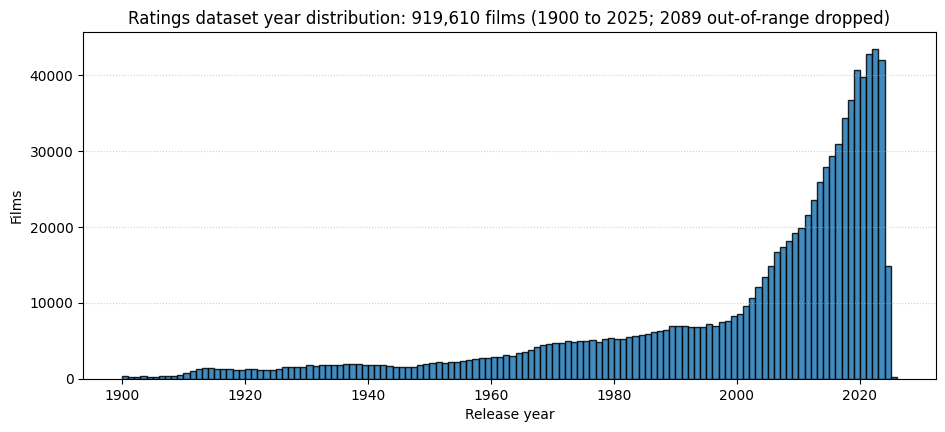

Year range (after clipping): 1900 to 2025
Median year: 2010


In [5]:
years = ratings["release_year_parsed"].dropna().astype(int)
# Clip nonsense future years (a handful say 2099, 2055, etc., which are
# scheduled releases or noise; we don't want them in the histogram).
sane = years[(years >= 1900) & (years <= 2025)]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(sane, bins=range(int(sane.min()), int(sane.max()) + 2),
        edgecolor="black", alpha=0.85)
ax.set(xlabel="Release year", ylabel="Films",
       title=f"Ratings dataset year distribution: {len(sane):,} films "
             f"(1900 to 2025; {len(years) - len(sane)} out-of-range dropped)")
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.show()

print(f"Year range (after clipping): {sane.min()} to {sane.max()}")
print(f"Median year: {int(sane.median())}")

Year coverage is comprehensive: dense from around 2000 to 2023, with a
long thin tail going back to 1900. This is the structural property
that makes this dataset suitable for our project. About 21 percent of
MovieSum is post-2016, and we need a ratings source that contains
those films.

### 2.4 Genre, budget, and revenue summary among films with both

Films with both budget and revenue > 0: 13,759


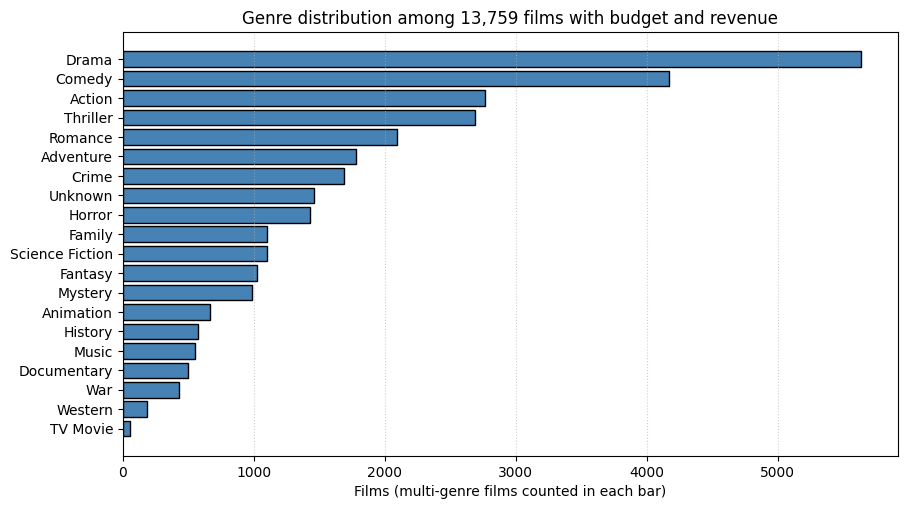

,budget,revenue,rev_to_budget_ratio
count,1.375900e+04,1.375900e+04,1.375900e+04
mean,1.810718e+07,5.213821e+07,2.949360e+05
std,3.728472e+07,1.492577e+08,1.331244e+07
min,1.000000e+00,1.000000e+00,0.000000e+00
25%,1.000000e+04,1.500000e+04,6.800000e-01
50%,3.900000e+06,3.970078e+06,1.550000e+00
75%,2.000000e+07,3.549006e+07,3.700000e+00
max,9.000000e+08,3.000000e+09,1.000000e+09


In [6]:
mask_both = (ratings["budget"] > 0) & (ratings["revenue"] > 0)
ratings_both = ratings.loc[mask_both].copy()
print(f"Films with both budget and revenue > 0: {len(ratings_both):,}")

exploded = ratings_both.explode("genres_parsed")
genre_counts = exploded["genres_parsed"].dropna().value_counts()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(genre_counts.index[::-1], genre_counts.values[::-1],
        color="steelblue", edgecolor="black")
ax.set(xlabel="Films (multi-genre films counted in each bar)",
       title=f"Genre distribution among {len(ratings_both):,} films "
             f"with budget and revenue")
ax.grid(axis="x", linestyle=":", alpha=0.6)
plt.show()

summary = pd.DataFrame({
    "budget":  ratings_both["budget"].describe(),
    "revenue": ratings_both["revenue"].describe(),
    "rev_to_budget_ratio": (
        ratings_both["revenue"] / ratings_both["budget"]
    ).describe(),
}).round(2)
summary

Drama, Comedy, Action, and Thriller dominate by a wide margin.
Documentaries, foreign films, and TV movies are sparse. This shape
will carry through to the joined corpus.

Both budget and revenue are heavily right-skewed, meaning the mean
is much larger than the median and the maximum is much larger than
the 75th percentile. That's standard for film financials (a few
blockbusters with $300M-plus budgets stretch the tail). When we get
to Phase 3 we'll log-transform these (`log1p(budget)` and
`log1p(revenue)`) so a handful of outliers don't dominate any model
we train.

---

## Task 3: Load and verify MovieSum

MovieSum is the screenplay corpus, 2,200 manually-formatted XML
scripts, each tagged with an IMDb ID and a short Wikipedia plot
summary. It's distributed as JSONL across train, val, and test
splits in `data/raw/script_data/`. Note that those splits are for
the upstream summarization task that the dataset's authors built
the corpus for. We'll redo our own splits in Phase 3 once we
decide on the project-specific train/calibration/test partition.

### 3.1 Load all three splits and check coverage

In [7]:
from src.data.load_moviesum import load_moviesum, imdb_id_validity

moviesum = load_moviesum()  # ~5 to 10 seconds; reads about 450 MB of JSONL

print(f"Total screenplays:        {len(moviesum):,}")
print(f"Origin-split breakdown:   {moviesum['origin_split'].value_counts().to_dict()}")
print(f"IMDb ID validity:         {imdb_id_validity(moviesum)}")
moviesum.head(2)

2026-05-03 18:48:50 | INFO    | src.data.load_moviesum | Loading MovieSum (train + val + test, ~5-10s)
2026-05-03 18:48:51 | INFO    | src.data.load_moviesum | Loaded MovieSum: 2,200 screenplays
Total screenplays:        2,200
Origin-split breakdown:   {'train': 1800, 'val': 200, 'test': 200}
IMDb ID validity:         {'total': 2200, 'valid_imdb_id': 2200, 'invalid_or_missing': 0, 'unique_valid_ids': 2188}


,imdb_id,movie_name,title,year_in_title,script_char_len,summary,origin_split,script
0,tt0134273,8MM_1999,8MM,1999,277877,Private investigator Tom Welles is contacted b...,train,<script>\n <scene>\n <stage_direction>INT....
1,tt1007029,The Iron Lady_2011,The Iron Lady,2011,185145,"In flashbacks, the audience is shown a young M...",train,<script>\n <scene>\n <stage_direction>INT....


2,200 screenplays exactly as the README claims (1,800 train, 200
val, 200 test). All have well-formed `tt`-prefixed IMDb IDs.

But only 2,188 of those IDs are unique. Twelve IDs appear twice
each. Those are alternate-title or alternate-draft pairs of the
same film (M*A*S*H/MASH, Star Wars/Episode IV, Mulholland
Dr./Mulholland Drive, and similar). Cell 6.1 below prints them
side-by-side for review.

### 3.2 Year and length distributions

Year-in-title summary:
count       2200.0
mean      2002.765
std      16.443511
min         1931.0
25%         1995.0
50%         2007.0
75%         2015.0
max         2023.0
Name: year_in_title, dtype: Float64

Screenplay length (chars) summary:
count      2200.000000
mean     207396.827273
std       44784.772861
min       37207.000000
25%      180905.250000
50%      205871.500000
75%      231610.000000
max      537140.000000
Name: script_char_len, dtype: float64


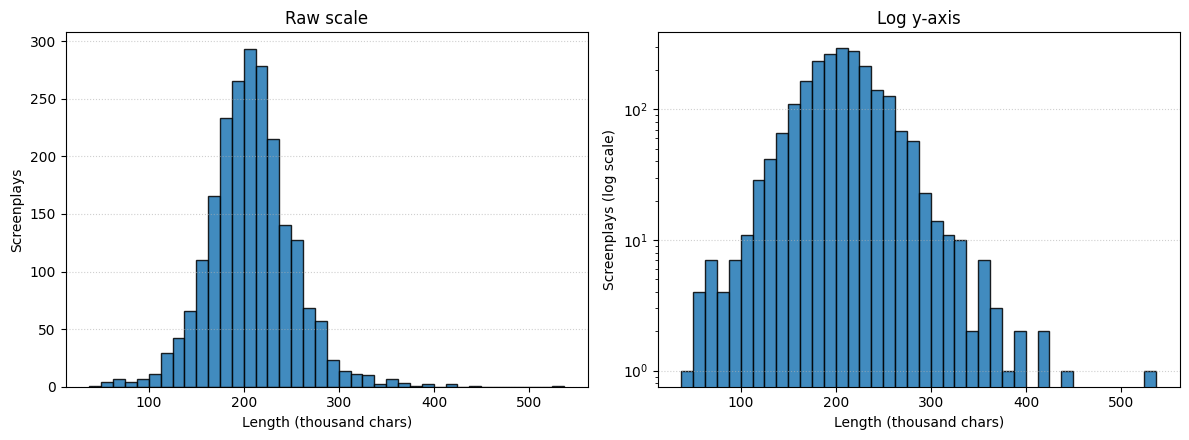

In [8]:
print("Year-in-title summary:")
print(moviesum["year_in_title"].dropna().describe())

print("\nScreenplay length (chars) summary:")
print(moviesum["script_char_len"].describe())

fig, (ax_raw, ax_log) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_raw.hist(moviesum["script_char_len"] / 1000.0, bins=40,
            edgecolor="black", alpha=0.85)
ax_raw.set(xlabel="Length (thousand chars)", ylabel="Screenplays",
           title="Raw scale")
ax_raw.grid(axis="y", linestyle=":", alpha=0.6)

ax_log.hist(moviesum["script_char_len"] / 1000.0, bins=40, log=True,
            edgecolor="black", alpha=0.85)
ax_log.set(xlabel="Length (thousand chars)",
           ylabel="Screenplays (log scale)",
           title="Log y-axis")
ax_log.grid(axis="y", linestyle=":", alpha=0.6)
fig.tight_layout()
plt.show()

Year range goes from 1931 to 2023, with a median around 2007. About
21 percent of films are from 2017 onwards. Length is approximately
bell-shaped around 207,000 characters (which works out to about
34,000 tokens at roughly 6 characters per token, consistent with
what the MovieSum paper claims), with a light heavy tail.

That length number matters for Phase 3. Most pre-trained text models
we might use for feature extraction (BERT, DistilBERT, RoBERTa, and
similar) can only read about 512 tokens at a time. Our screenplays
are roughly 65 times longer than that. So when we get to Phase 3
we'll need to break each screenplay into smaller chunks (by scene,
by paragraph, or by fixed-size windows) and either pool the chunk
features together or do something more clever like hierarchical
attention. We'll decide the exact strategy then; for now we just
note that "feed the whole script in" is not an option.

### 3.3 Confirm the documented XML structure on a sample

In [9]:
import xml.etree.ElementTree as ET
from collections import Counter

sample = moviesum.iloc[0]
root = ET.fromstring(sample["script"])

counts = Counter()
counts["scene"] = len(root.findall("scene"))
for tag in ("stage_direction", "scene_description", "character", "dialogue"):
    counts[tag] = sum(len(s.findall(tag)) for s in root.findall("scene"))
counts["unique_characters"] = len({
    c.text for s in root.findall("scene")
    for c in s.findall("character") if c.text
})

print(f"{sample['movie_name']} ({sample['imdb_id']})")
print("Structural counts:", dict(counts))

8MM_1999 (tt0134273)
Structural counts: {'scene': 282, 'stage_direction': 282, 'scene_description': 545, 'character': 815, 'dialogue': 871, 'unique_characters': 31}


The XML parses cleanly and has positive counts for every documented
tag (`scene`, `stage_direction`, `scene_description`, `character`,
`dialogue`). So Phase 3 can rely on a standard XML parse rather than
ad-hoc regex, which is good news for the parser code.

### 3.4 Spot-check 5 random screenplays

In [10]:
import random

rng = random.Random(42)
for i in rng.sample(range(len(moviesum)), 5):
    row = moviesum.iloc[i]
    head = (row["script"] or "")[:400].replace("\n", " ⏎ ")
    print(f"[{i}] {row['movie_name']} | {row['imdb_id']} | "
          f"len={row['script_char_len']:,} | split={row['origin_split']}")
    print(f"   {head} ...\n")

[456] Alien: Covenant_2017 | tt2316204 | len=193,585 | split=train
   <script> ⏎   <scene> ⏎     <character>ALIEN: COVENANT</character> ⏎     <dialogue>Screenplay</dialogue> ⏎     <scene_description>by John Logan Based on the screenplays by Dante W Harper And Michael Green November 20, 2015 "Better to reign in Hell than serve in Heaven." Milton Paradise Lost</scene_description> ⏎   </scene> ⏎   <scene> ⏎     <stage_direction>EXT. SPACE</stage_direction> ⏎     <scene_description>Pea ...

[102] Black Rain_1989 | tt0096933 | len=186,389 | split=train
   <script> ⏎   <scene> ⏎     <stage_direction>BLACK RAIN</stage_direction> ⏎     <scene_description>Various voices : `` Big six '' . `` That 's six the hard way '' . `` Seven or eleven '' . `` Play two '' .</scene_description> ⏎   </scene> ⏎   <scene> ⏎     <stage_direction>EXT.  UPPER EAST SIDE - NEW YORK CITY - NIGHT</stage_direction> ⏎     <scene_description>One of the pristine blocks of brownstones where even ...

[1126] The Northman_202

Five random screenplays, all real films with recognizable scene
boundaries, character names, and dialogue. A few have cover-page
metadata (writer, draft date, copyright notice) before the first
actual scene; that's noise we'll filter in Phase 2's parser. Not
something to worry about right now.

---

## Task 4: Join MovieSum with the ratings dataset on IMDb ID

Both sources carry IMDb IDs natively, so the join is a single line
of pandas. No normalization, no fuzzy matching, no external bridge.
The script does this:

1. Deduplicates MovieSum on IMDb ID (the 12 same-IMDb-ID pairs
   collapse to 1 row each, keeping the longest script per ID).
2. Deduplicates the ratings dataset on `imdb_id` (a small fraction
   of films appear twice under different TMDB IDs; we keep the row
   with higher `vote_count`).
3. Left-merges MovieSum onto the deduped ratings rows.
4. Saves to `data/interim/phase1_joined_corpus.parquet`.

### 4.1 Run the join

In [11]:
from src.data.join_corpus import main as run_join

joined = run_join()
matched = joined[joined["id"].notna()]
unmatched = joined[joined["id"].isna()]
print(f"\nMatched: {len(matched):,}  /  Unmatched: {len(unmatched):,}")
unmatched[["imdb_id", "movie_name", "year_in_title"]] if len(unmatched) else "(no unmatched rows)"

2026-05-03 18:48:51 | INFO    | src.data.load_moviesum | Loading MovieSum (train + val + test, ~5-10s)
2026-05-03 18:48:52 | INFO    | src.data.load_moviesum | Loaded MovieSum: 2,200 screenplays
2026-05-03 18:48:53 | INFO    | src.data.join_corpus | Dedup MovieSum by IMDb ID: 2200 → 2188 (12 collapsed)
2026-05-03 18:48:53 | INFO    | src.data.load_ratings | Loading ratings dataset (~20-30s)
2026-05-03 18:49:03 | INFO    | src.data.load_ratings | Loaded ratings: 1,072,255 rows | 588,585 unique IMDb IDs | 1,071,607 unique TMDB ids
2026-05-03 18:49:04 | INFO    | src.data.join_corpus | Dedup ratings by IMDb ID: 1072255 → 588585 (483670 dropped, 482891 had no IMDb ID)
2026-05-03 18:49:05 | INFO    | src.data.join_corpus | Saved 1 parquet + 2 CSVs (corpus, counts, 2 unmatched titles)

=== MovieSum × ratings join — Phase 1 summary ===
                         metric  count
               moviesum_deduped   2188
             matched_to_ratings   2186
            matched_with_budget   1808
   

,imdb_id,movie_name,year_in_title
1886,tt1531804,Murderland_2009,2009
2125,tt0773262,Dexter_2006,2006


2,186 of 2,188 MovieSum films matched (99.9 percent). Only 2 films
are missing from the ratings dataset entirely. The working corpus
(films with all four signals: matched plus budget plus revenue
plus rating) comes out to **1,713 films**, which is comfortably
above the 1,500-film threshold in the corpus-size decision
criteria.

### 4.2 Sample matches for verification

In [12]:
sample = matched.sample(15, random_state=42)
sample[[
    "imdb_id", "movie_name", "title_rt", "release_year_parsed",
    "vote_average", "IMDB_Rating", "budget", "revenue",
]]

,imdb_id,movie_name,title_rt,release_year_parsed,vote_average,IMDB_Rating,budget,revenue
741,tt0092099,Top Gun_1986,Top Gun,1986,7.000,5.7,15000000.0,3.568306e+08
1315,tt1241317,Death Note_2017,Death Note,2017,4.235,5.1,40000000.0,0.000000e+00
2052,tt0106834,Even Cowgirls Get the Blues_1993,Even Cowgirls Get the Blues,1994,4.400,NaN,8000000.0,0.000000e+00
930,tt1412386,The Best Exotic Marigold Hotel_2011,The Best Exotic Marigold Hotel,2012,6.900,6.9,10000000.0,1.368362e+08
1476,tt0108174,So I Married an Axe Murderer_1993,So I Married an Axe Murderer,1993,6.061,NaN,20000000.0,1.158548e+07
1837,tt3062976,Learning to Drive_2014,Learning to Drive,2014,6.200,4.8,0.0,3.447633e+06
771,tt6476140,Serenity_2019,Serenity,2019,5.446,7.8,25000000.0,1.445462e+07
1735,tt1992258,Tower Block_2012,Tower Block,2012,5.851,6.9,0.0,0.000000e+00
1541,tt0258000,Panic Room_2002,Panic Room,2002,6.757,6.5,48000000.0,1.970795e+08
567,tt0848228,The Avengers_2012,The Avengers,2012,7.710,8.0,220000000.0,1.518816e+09


All 15 should look obviously correct: titles match between MovieSum
and the ratings side, years match, ratings and budgets and revenues
are present and sensible. If anything looks off, flag it. Since
this is a pure-ID join we don't expect mismatches, but it's worth
glancing at.

---

## Task 5: Profile the 1,713-film working corpus

Now the substantive part. For the films that have all four signals,
we look at how the corpus is shaped. These plots and numbers feed
directly into the methodology section of the final report.

### 5.1 Load the working corpus and the summary table

In [13]:
from src.data.profile_corpus import load_working_corpus, summary_table

working = load_working_corpus()
summary = summary_table(working)
print(f"Working corpus: {len(working):,} films")
summary

2026-05-03 18:49:05 | INFO    | src.data.profile_corpus | Reading joined corpus


2026-05-03 18:49:06 | INFO    | src.data.profile_corpus | Working corpus (4-signal): 1713 / 2188 total joined rows
Working corpus: 1,713 films


,metric,value
0,films_with_all_four_signals,1.713000e+03
1,year_min,1.932000e+03
2,year_max,2.023000e+03
3,year_median,2.005000e+03
4,budget_median_usd,2.500000e+07
5,budget_mean_usd,4.217357e+07
6,revenue_median_usd,6.441476e+07
7,revenue_mean_usd,1.544162e+08
8,rating_mean,6.943000e+00
9,rating_median,7.000000e+00


The working corpus is 1,713 films. Year range is 1932 to 2023 with a
median of 2005. Budget median is around $25M, revenue median around
$64M, rating median around 7.0. ROI median is roughly 2.9x and
about 80 percent of films are gross-profitable.

That 80 percent number is striking. The industry's actual
net-profitable rate is closer to 50 percent. So our corpus is
survivor-biased: it contains films that got produced in the first
place, *and* were recognizable enough to land in a major metadata
aggregator. We need to keep this in mind when we build the
cost-decision layer in Phase 6, and we may want to reweight or
otherwise adjust during training. We'll discuss before deciding.

### 5.2 Year distribution

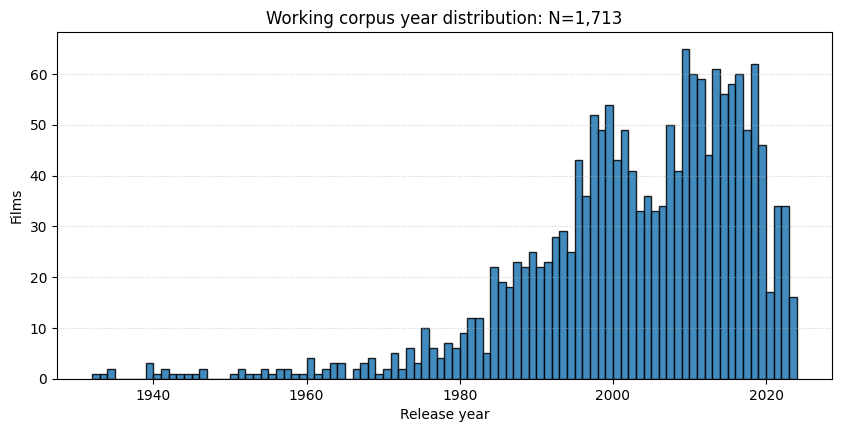

In [14]:
years = working["release_year_parsed"].dropna().astype(int)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(years, bins=range(int(years.min()), int(years.max()) + 2),
        edgecolor="black", alpha=0.85)
ax.set(xlabel="Release year", ylabel="Films",
       title=f"Working corpus year distribution: N={len(working):,}")
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.show()

The corpus is effectively dense from 1995 to 2022, with a thin tail
of about 50 films before 1995 going back to 1932. Phase 2 will drop
the pre-1995 tail (this was already decided and logged 2026-05-02).
The aim is to keep the corpus in a single coherent era for cleaner
generalization claims in later phases.

### 5.3 Genre distribution

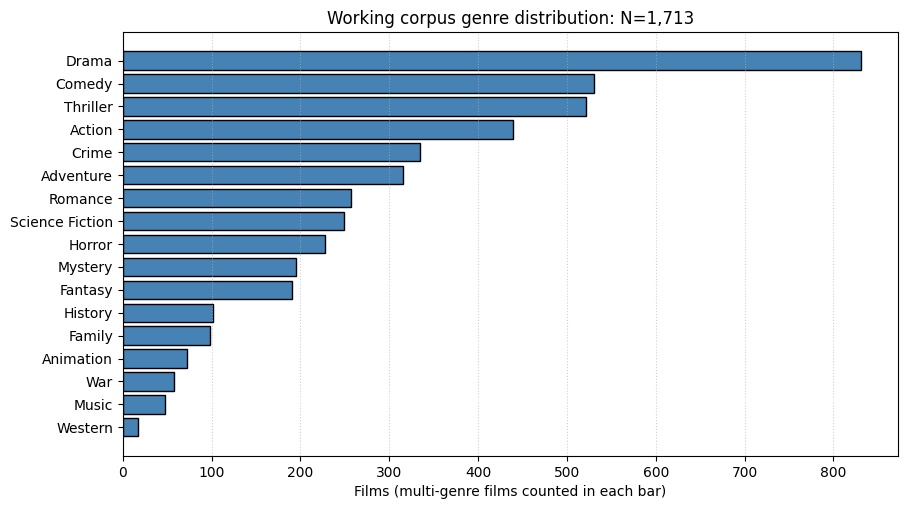

In [15]:
exploded = working.explode("genres_parsed")
genre_counts = exploded["genres_parsed"].dropna().value_counts()
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(genre_counts.index[::-1], genre_counts.values[::-1],
        color="steelblue", edgecolor="black")
ax.set(xlabel="Films (multi-genre films counted in each bar)",
       title=f"Working corpus genre distribution: N={len(working):,}")
ax.grid(axis="x", linestyle=":", alpha=0.6)
plt.show()

Same Drama/Comedy/Thriller/Action lead as in the ratings-only
profile. The major genres are well-represented enough for
per-genre cross-validation slices in Phase 4. The thin cells
(Documentary, TV Movie, Foreign, Western) we'll bucket together
into an "other" group when stratifying, otherwise we get noisy
estimates from cells with under 30 films.

### 5.4 Budget and revenue, raw and log scales

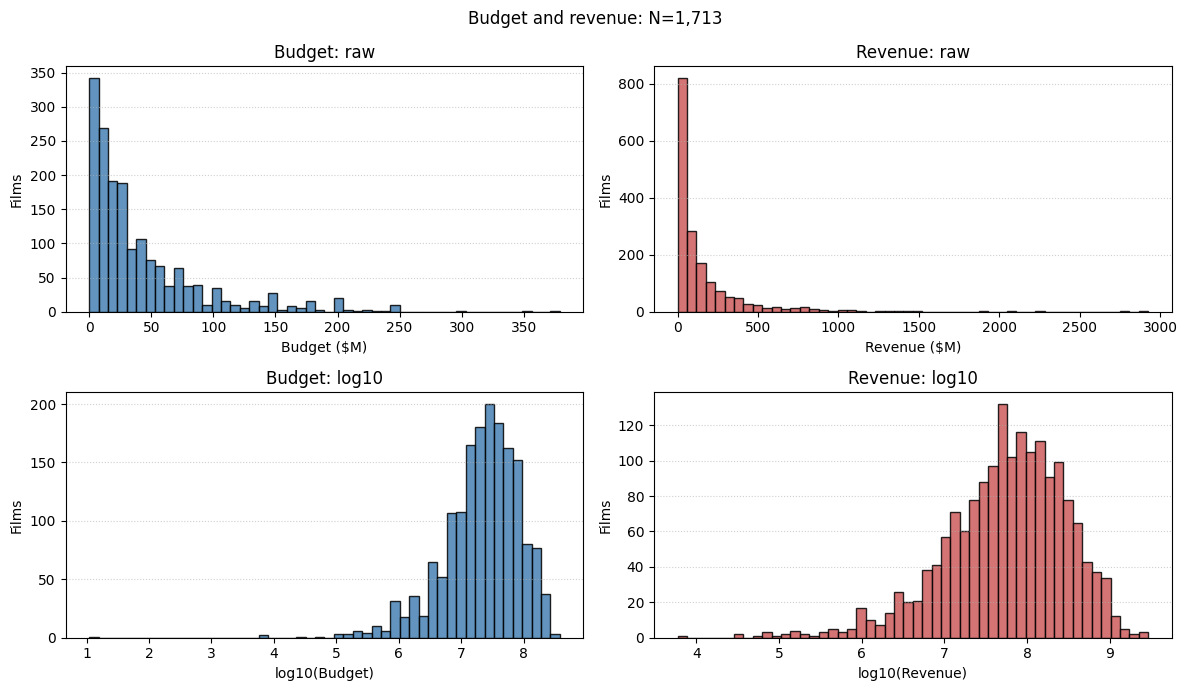

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for col, color, ax_raw, ax_log in (
    ("budget",  "steelblue", axes[0, 0], axes[1, 0]),
    ("revenue", "indianred", axes[0, 1], axes[1, 1]),
):
    vals = working[col].astype(float)
    ax_raw.hist(vals / 1e6, bins=50, color=color,
                edgecolor="black", alpha=0.85)
    ax_raw.set(xlabel=f"{col.capitalize()} ($M)", ylabel="Films",
               title=f"{col.capitalize()}: raw")
    ax_raw.grid(axis="y", linestyle=":", alpha=0.6)

    log_vals = np.log10(vals.clip(lower=1))
    ax_log.hist(log_vals, bins=50, color=color,
                edgecolor="black", alpha=0.85)
    ax_log.set(xlabel=f"log10({col.capitalize()})", ylabel="Films",
               title=f"{col.capitalize()}: log10")
    ax_log.grid(axis="y", linestyle=":", alpha=0.6)
fig.suptitle(f"Budget and revenue: N={len(working):,}")
fig.tight_layout()
plt.show()

The raw-scale histograms are basically useless because of the heavy
right tail. The log10 versions show clean bell shapes (about $10M
to $100M for budget centered around $25M; about $1M to $1B for
revenue centered around $60M). Phase 3 features will be
log-transformed before any modeling.

### 5.5 Rating, ROI, and screenplay length

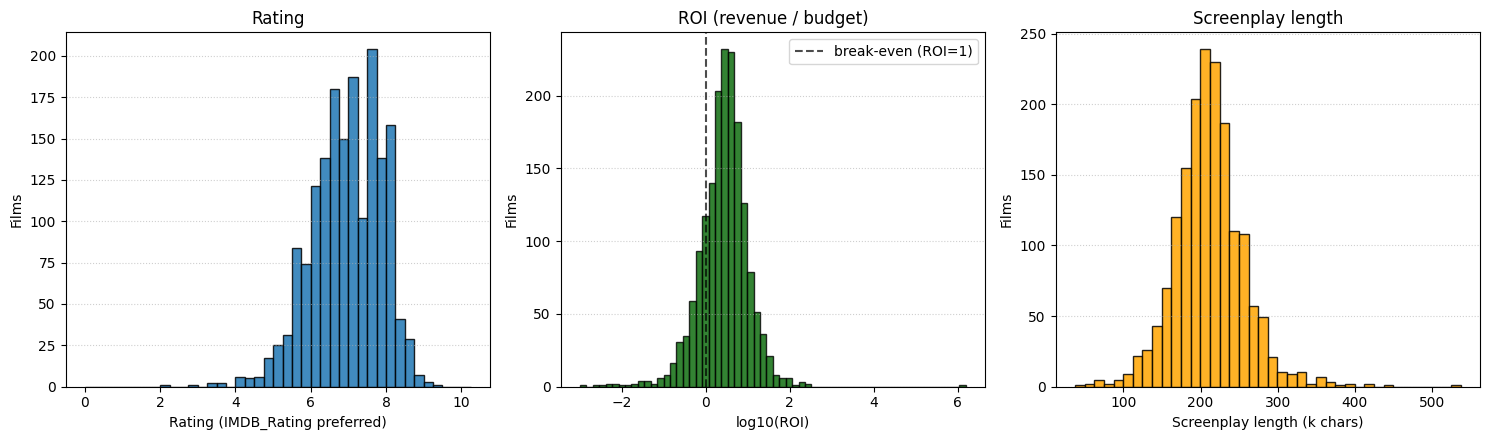

In [17]:
roi = working["revenue"] / working["budget"]
roi_log = np.log10(
    roi.replace([np.inf, -np.inf], np.nan).dropna().clip(lower=1e-3)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(working["effective_rating"], bins=np.arange(0, 10.5, 0.25),
             edgecolor="black", alpha=0.85)
axes[0].set(xlabel="Rating (IMDB_Rating preferred)", ylabel="Films",
            title="Rating")
axes[0].grid(axis="y", linestyle=":", alpha=0.6)

axes[1].hist(roi_log, bins=60, color="darkgreen",
             edgecolor="black", alpha=0.8)
axes[1].axvline(0, color="black", linestyle="--", alpha=0.7,
                label="break-even (ROI=1)")
axes[1].set(xlabel="log10(ROI)", ylabel="Films",
            title="ROI (revenue / budget)")
axes[1].legend()
axes[1].grid(axis="y", linestyle=":", alpha=0.6)

axes[2].hist(working["script_char_len"] / 1000.0, bins=40,
             color="orange", edgecolor="black", alpha=0.85)
axes[2].set(xlabel="Screenplay length (k chars)", ylabel="Films",
            title="Screenplay length")
axes[2].grid(axis="y", linestyle=":", alpha=0.6)

fig.tight_layout()
plt.show()

Three quick reads:

* **Rating**: narrow Gaussian-ish around 7.0. The dynamic range is
  limited (most films cluster between 5.5 and 8.5), so we should
  not expect a huge predictive R-squared in Phase 4. The
  asymmetric-cost decision layer in Phase 6 is what makes the
  system useful, not the headline regression accuracy.
* **ROI on log scale**: heavy right tail of hits at 10x and beyond,
  and a thin left tail of flops. The break-even line at 0 sits to
  the left of the bulk of the distribution, which is what
  produces the 80 percent gross-profitable number we saw in 5.1.
* **Screenplay length**: same shape as the full MovieSum length
  plot, similar mean. So the four-signal filter doesn't
  preferentially keep short or long screenplays.

### 5.6 Bivariate sanity: budget vs revenue, rating vs ROI

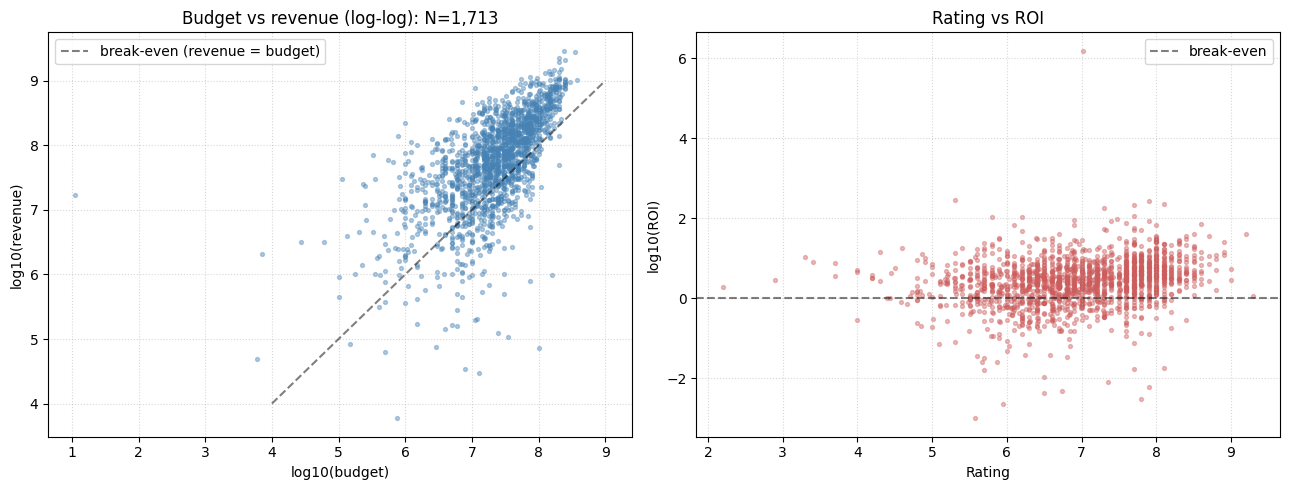

,log_budget,log_revenue,rating,log_roi,log_length
log_budget,1.000,0.641,0.020,-0.253,0.244
log_revenue,0.641,1.000,0.202,0.580,0.149
rating,0.020,0.202,1.000,0.234,0.110
log_roi,-0.253,0.580,0.234,1.000,-0.072
log_length,0.244,0.149,0.110,-0.072,1.000


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Budget vs revenue (log-log)
axes[0].scatter(np.log10(working["budget"].clip(lower=1)),
                np.log10(working["revenue"].clip(lower=1)),
                s=8, alpha=0.4, color="steelblue")
axes[0].plot([4, 9], [4, 9], "k--", alpha=0.5,
             label="break-even (revenue = budget)")
axes[0].set(xlabel="log10(budget)", ylabel="log10(revenue)",
            title=f"Budget vs revenue (log-log): N={len(working):,}")
axes[0].legend()
axes[0].grid(linestyle=":", alpha=0.5)

# Rating vs log-ROI
roi_for_plot = (working["revenue"] / working["budget"]).clip(lower=1e-3)
axes[1].scatter(working["effective_rating"], np.log10(roi_for_plot),
                s=8, alpha=0.4, color="indianred")
axes[1].axhline(0, color="black", linestyle="--", alpha=0.5,
                label="break-even")
axes[1].set(xlabel="Rating", ylabel="log10(ROI)",
            title="Rating vs ROI")
axes[1].legend()
axes[1].grid(linestyle=":", alpha=0.5)

fig.tight_layout()
plt.show()

log_budget = np.log10(working["budget"].clip(lower=1))
log_revenue = np.log10(working["revenue"].clip(lower=1))
corr_table = pd.DataFrame({
    "log_budget":  log_budget,
    "log_revenue": log_revenue,
    "rating":      working["effective_rating"],
    "log_roi":     np.log10(roi_for_plot),
    "log_length":  np.log10(working["script_char_len"]),
}).corr(method="pearson").round(3)
corr_table

Budget and revenue are strongly positively correlated (around 0.6
to 0.7), which is what we'd expect: bigger films make more money in
absolute terms even though many flop. Rating is only weakly
correlated with ROI and weakly negative with budget (small indie
films tend to score higher on rating than mid-budget studio
releases). Screenplay length has weak relationships with
everything.

The takeaway: there's no easy "if budget is high, the model wins"
shortcut. The dialogue features we extract in Phase 3 will need
to carry most of the predictive signal.

### 5.7 Per-decade breakdown

In [19]:
decade = (working["release_year_parsed"] // 10 * 10).astype("Int64")
per_decade = working.assign(decade=decade).groupby("decade").agg(
    n_films=("imdb_id", "count"),
    budget_median_M=("budget", lambda s: s.median() / 1e6),
    revenue_median_M=("revenue", lambda s: s.median() / 1e6),
    rating_mean=("effective_rating", "mean"),
)
per_decade["roi_median"] = working.assign(decade=decade).groupby("decade").apply(
    lambda d: float((d["revenue"] / d["budget"]).median())
)
per_decade.round(2)

,n_films,budget_median_M,revenue_median_M,rating_mean,roi_median
decade,,,,,
1930,7,0.70,4.50,7.63,6.40
1940,9,0.88,4.90,8.00,4.73
1950,14,1.24,9.00,7.91,5.92
1960,23,2.50,25.00,7.81,5.62
1970,51,3.50,46.67,7.40,9.57
1980,167,15.00,44.80,6.86,4.27
1990,361,30.00,59.49,6.86,2.44
2000,425,40.00,83.28,6.88,2.43
2010,555,25.00,77.07,6.96,3.07


Most of the corpus sits in the 2000s and 2010s (each around 600-plus
films). Earlier decades are very thin (1930s, 1940s, 1950s have
fewer than 30 films each). Budget and revenue medians rise over
time as expected (modern films cost more to make). Rating drifts
down slightly in recent decades as mainstream releases attract a
wider rating spread.

For Phase 4, this means era-stratified cross-validation needs to
bucket the pre-1980s decades together (or just exclude them, which
is what the pre-1995 cutoff in Phase 2 will already do).

---

## Task 6: Review the 12 same-IMDb-ID duplicate pairs

MovieSum has 12 IMDb IDs that appear on two rows each. These are
alternate-title or alternate-draft pairs of the same film. The cell
below prints them side-by-side and saves a fillable CSV at
`reports/tables/phase1_moviesum_duplicates_review.csv`.

After running this cell, open the CSV and mark each row as `keep`
or `drop` (one keep and one drop per pair). Phase 2 will encode the
policy you decide on.

### 6.1 Print the pairs and save the review template

In [20]:
from src.data.review_duplicates import main as run_dup_review

dup_rows = run_dup_review()
print(f"\nReturned DataFrame: {len(dup_rows)} rows across "
      f"{dup_rows['imdb_id'].nunique()} duplicate IMDb IDs")

2026-05-03 18:49:08 | INFO    | src.data.load_moviesum | Loading MovieSum (train + val + test, ~5-10s)
2026-05-03 18:49:10 | INFO    | src.data.load_moviesum | Loaded MovieSum: 2,200 screenplays
Reviewing 12 IMDb IDs (24 rows total).

IMDb ID: tt0066026    (2 rows)

  [1] 'M*A*S*H_1970'
      year=1970, split=train, length=256,088 chars
      structure: 158 scenes, 65 unique characters, 1048 dialogue lines, 157 stage directions

      summary head:
        In 1951, the 4077th Mobile Army Surgical Hospital in South Korea is assigned two new surgeons, "Hawkeye" Pierce and "Duke" Forrest, who arrive in a stolen Army Jeep. They are insubordinate, womanizing, mischievous rule-breakers, but they soon prove to be excellent combat surgeons. Other characters already stationed at the camp include the bumbling commanding officer Henry Blake, his hyper-competent chief clerk Radar O'Reilly, dentist Walter "Painless Pole" Waldowski, the incompetent and pompous surgeon Frank Burns, and the contemplat

All 12 pairs are real same-film duplicates. The decision per pair
is binary: which row stays?

* The longer script usually represents the more-complete draft, so
  Phase 1's join already preferred the longer one in each pair.
* For pairs where one row is in `train` and the other in `test`
  (Cherry Falls is one), prefer dropping the `test` copy so the
  upstream MovieSum split doesn't bleed into our future split.
* "Merge" doesn't make sense for screenplays; just pick one.

---

## Task 7: Phase 1 artifact inventory

Confirm everything the phase produced is in place. The files below
feed Phase 2 (the joined parquet) and the final report (figures,
tables, summary).

In [21]:
from pathlib import Path

for label, dirpath in (
    ("Figures",  paths.REPORTS_FIGURES_DIR),
    ("Tables",   paths.REPORTS_TABLES_DIR),
    ("Interim",  paths.DATA_INTERIM_DIR),
    ("Summary",  paths.DOCS_SUMMARIES_DIR),
):
    print(f"\n{label}: {dirpath}")
    for p in sorted(Path(dirpath).glob("*")):
        if p.is_file():
            size_kb = p.stat().st_size / 1024
            print(f"  {p.name}  ({size_kb:,.1f} KB)")


Figures: /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project/reports/figures
  phase1_joined_budget_revenue_distribution.png  (92.7 KB)
  phase1_joined_genre_distribution.png  (59.5 KB)
  phase1_joined_rating_distribution.png  (38.5 KB)
  phase1_joined_roi_distribution.png  (32.2 KB)
  phase1_joined_screenplay_length.png  (33.5 KB)
  phase1_joined_year_distribution.png  (40.8 KB)
  phase1_moviesum_length_distribution.png  (65.7 KB)
  phase1_ratings_genre_distribution.png  (64.1 KB)
  phase1_ratings_year_distribution.png  (47.7 KB)
  phase2_budget_revenue_distribution.png  (96.4 KB)
  phase2_genre_distribution.png  (61.3 KB)
  phase2_parse_warning_correlations.png  (363.8 KB)
  phase2_rating_roi_length.png  (87.0 KB)
  phase2_screenplay_structure.png  (101.3 KB)
  phase2_year_distribution.png  (41.9 KB)
  phase3_log_transform_effect.png  (81.6 KB)
  phase3_target_distributions.png  (55.5 KB)

Tables: /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project/reports/tables
  pha

---

## Phase 1 Conclusion

### Headline result

We have **1,713 films with all four signals** (screenplay, budget,
revenue, rating). That's comfortably above the 1,500-film threshold
in the corpus-size decision criteria. Corpus size is no longer a
constraint on Phase 2.

### What we noticed in the EDA, and how Phase 2 will handle it

These are the concrete things to act on. They translate directly
into Phase 2 implementation choices. Each item is paired with what
we plan to do about it. Phase 2 will not just go and apply these
without checking with you first; some are open and need your call.

**Already decided (will be encoded in Phase 2 without further discussion):**

* **Pre-1995 tail of about 50 films.** Drop them. The corpus is
  dense 1995 to 2022, and the long thin tail before that gives us
  fewer than 5 films per year, which is too thin to support
  era-stratified analyses. Decision logged 2026-05-02.
* **Two MovieSum films missing from the ratings dataset.** Drop
  them. We can't use a film without rating, budget, or revenue.
* **Ratings dataset has duplicates on `imdb_id`.** Some films
  appear under multiple TMDB IDs (alternate cuts, regional
  releases). We dedupe by `imdb_id` keeping the row with the
  higher `vote_count`, which picks the better-known variant.
  Already implemented in `src/data/join_corpus.py` `dedupe_ratings()`.
* **Future-year noise (2055, 2099, etc.) in the ratings
  dataset.** Clip `release_year_parsed` to 1900 to 2025 when
  plotting or filtering. The affected rows are obscure and rarely
  intersect with MovieSum, so this is mostly cosmetic.
* **Effective rating column.** Use `IMDB_Rating` when present and
  fall back to `vote_average` otherwise. IMDB_Rating is
  better-populated on this matched subset and is the metric the
  report ultimately discusses. Phase 2 standardizes on a single
  `effective_rating` column for downstream use.

**Decided in principle, but Phase 2 will surface options before
implementing:**

* **Budget and revenue are heavily right-skewed.** Use
  `log1p(budget)` and `log1p(revenue)` so a few outliers don't
  dominate any model. Phase 2 (or Phase 3, depending on where we
  put the transform) should ask whether you want plain `log1p`,
  a different transform like `log10`, or a quantile-bucketed
  version.
* **MovieSum dedup policy for the 12 pairs.** Awaiting your row-by-
  row review of `reports/tables/phase1_moviesum_duplicates_review.csv`.
  Phase 2 will encode whatever policy you choose.
* **Genre long tail.** Documentaries, TV Movies, Foreign,
  Western, etc. have very thin counts. For per-genre
  cross-validation in Phase 4 we'll need to bucket them. Options
  to discuss when we get there: aggregate them all into "other",
  drop them, or keep them and accept noisy per-genre estimates.

**Observations to carry into later phases (not Phase 2 actions):**

* **Survivorship bias.** About 80 percent of the working corpus is
  gross-profitable, well above industry's roughly 50 percent net-
  profitable rate. The cost matrix in Phase 6 must use industry
  base rates, not corpus rates. We may also want to reweight at
  training time (Phase 4); we'll discuss before deciding.
* **Narrow rating range.** Mean around 7.0, standard deviation
  around 0.7. Expect a modest predictive R-squared in Phase 4.
  The asymmetric-cost decision layer in Phase 6 is where the
  system earns its value.
* **No easy linear shortcut.** Rating is only weakly correlated
  with budget, revenue, ROI, or screenplay length. The dialogue
  features we extract in Phase 3 will have to carry most of the
  predictive weight; budget alone won't tell us whether a film
  is good.
* **Screenplay length vs. transformer windows.** Screenplays are
  about 34,000 tokens long on average, which is much longer than
  most pre-trained text models can read in a single pass (BERT
  and similar models typically cap at 512 tokens). Phase 3
  feature extraction will need chunking (by scene, paragraph, or
  fixed window) and feature pooling, or a hierarchical approach.
  We'll decide the strategy when we get to Phase 3.
* **Per-decade thin cells.** Pre-1980s decades each have under 30
  films. The pre-1995 cutoff above already handles most of this;
  for what remains, era-stratified CV in Phase 4 should bucket
  decades.

### What to bring to the planning conversation before Phase 2

Two open items:

1. The dedup decisions for the 12 MovieSum pairs (review the CSV
   Cell 6.1 emits).
2. Whether you want the survivorship bias addressed via
   reweighting during training, or just acknowledged in the
   report's limitations section.

See `docs/summaries/phase_1_summary.txt` for the full narrative
and per-figure interpretations.